In [1]:
from measurements import *
from ase.db import connect
import numpy as np
import matplotlib.pyplot as plt

In [2]:
frame = ase.io.read("xyz_files/duped_ellipsoids_with_axes.xyz")

In [3]:
base_dir = "simulations/multi_temp_trial"
temps = [50., 100., 150., 200., 250., 275., 300., 325., 350., 375., 400., 450.]

eq50db = f"{base_dir}/50.0/equilibration.db"
sim50db = f"{base_dir}/50.0/simulation.db"

eq100db = f"{base_dir}/100.0/equilibration.db"
sim100db = f"{base_dir}/100.0/simulation.db"

eq150db = f"{base_dir}/150.0/equilibration.db"
sim150db = f"{base_dir}/150.0/simulation.db"

eq200db = f"{base_dir}/200.0/equilibration.db"
sim200db = f"{base_dir}/200.0/simulation.db"

eq250db = f"{base_dir}/250.0/equilibration.db"
sim250db = f"{base_dir}/250.0/simulation.db"

eq275db = f"{base_dir}/275.0/equilibration.db"
sim275db = f"{base_dir}/275.0/simulation.db"

eq300db = f"{base_dir}/300.0/equilibration.db"
sim300db = f"{base_dir}/300.0/simulation.db"

eq325db = f"{base_dir}/325.0/equilibration.db"
sim325db = f"{base_dir}/325.0/simulation.db"

eq350db = f"{base_dir}/350.0/equilibration.db"
sim350db = f"{base_dir}/350.0/simulation.db"

eq375db = f"{base_dir}/375.0/equilibration.db"
sim375db = f"{base_dir}/375.0/simulation.db"

eq400db = f"{base_dir}/400.0/equilibration.db"
sim400db = f"{base_dir}/400.0/simulation.db"

eq450db = f"{base_dir}/450.0/equilibration.db"
sim450db = f"{base_dir}/450.0/simulation.db"

In [4]:
sims = [sim50db, sim100db, sim150db, sim200db, sim250db, sim275db, sim300db, sim325db, sim350db, sim375db, sim400db, sim450db]
results = []

for temp, db in zip(temps, sims):
    analyzer = TrajectoryAnalyzer(db)
    analyzer.add_measurement("RDF", RadialDistributionFunction(r_max=25., num_bins=100))
    analyzer.add_measurement("OCF", OrientationalCorrelationFunction(r_max=25., num_bins=100))
    analyzer.add_measurement("Heat Capacity", HeatCapacity(temp, len(frame)))
    analyzer.add_measurement("Average Energy", AverageEnergy())
    final_results = analyzer.run_analysis()
    results.append((temp, final_results))

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

...

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

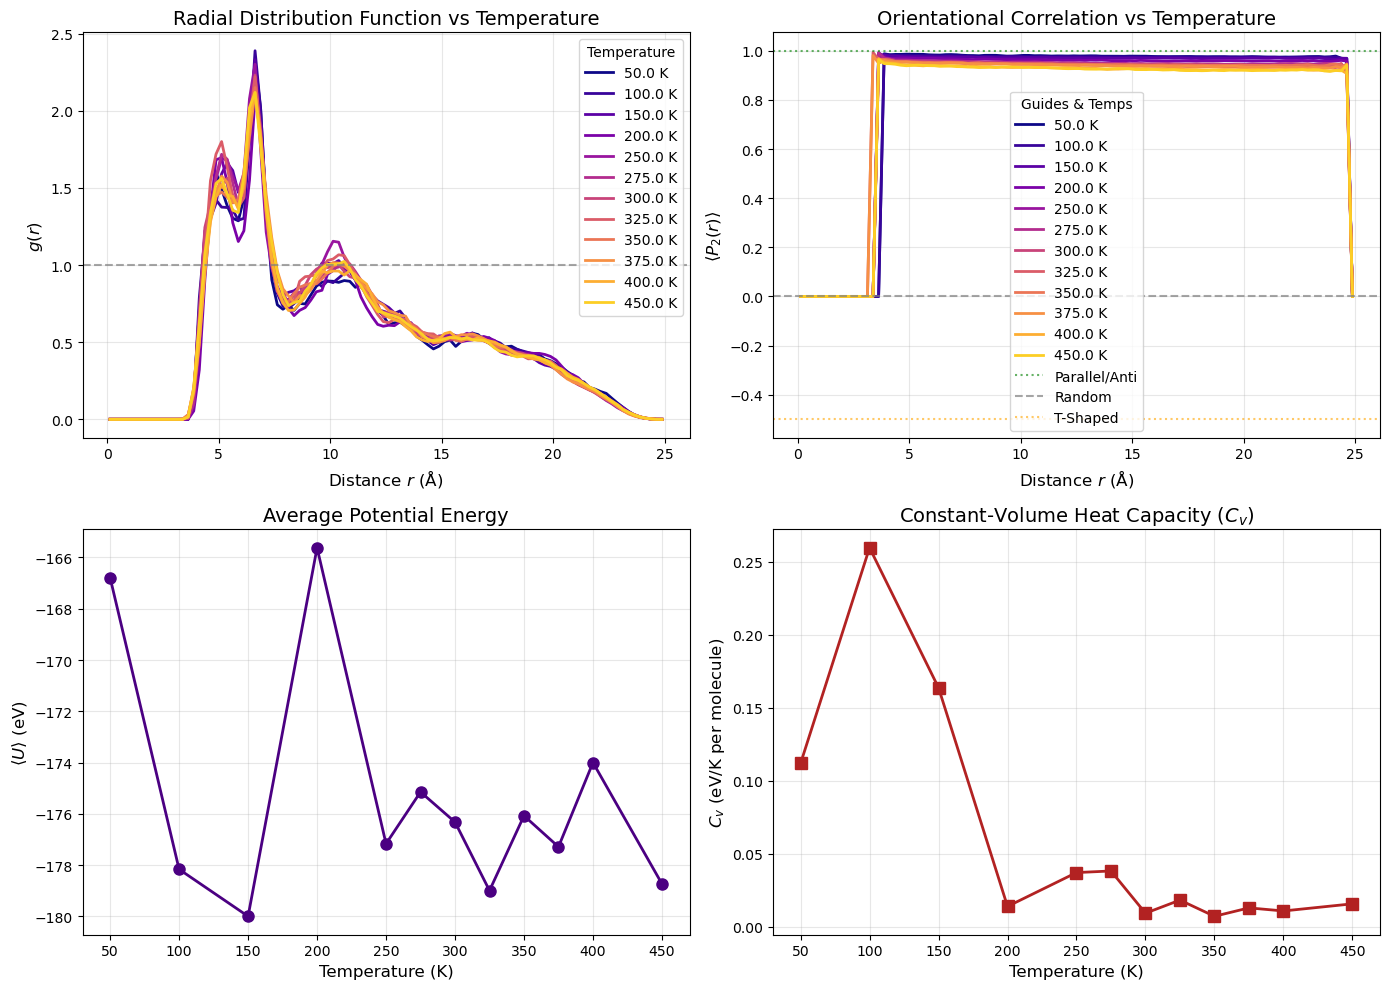

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_temperature_series(results):
    """
    Takes a list of tuples: [(temp, final_results_dict), ...]
    and plots the structural and thermodynamic properties across temperatures.
    """
    # Create a 2x2 dashboard
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    ax_rdf = axs[0, 0]
    ax_ocf = axs[0, 1]
    ax_energy = axs[1, 0]
    ax_cv = axs[1, 1]

    # Lists to store the scalar thermodynamic data
    temps = []
    energies = []
    heat_capacities = []

    # Colormap to make the temperature lines look nice (cool to warm)
    colors = plt.cm.plasma(np.linspace(0, 0.9, len(results)))

    for i, (temp, res) in enumerate(results):
        temps.append(temp)

        # 1. Plot RDF (Superimposed)
        if "RDF" in res:
            r = res["RDF"]["r"]
            g_r = res["RDF"]["g_r"]
            ax_rdf.plot(r, g_r, label=f"{temp} K", color=colors[i], linewidth=2)

        # 2. Plot OCF (Superimposed)
        if "OCF" in res:
            r = res["OCF"]["r"]
            s2_r = res["OCF"]["s2_r"]
            ax_ocf.plot(r, s2_r, label=f"{temp} K", color=colors[i], linewidth=2)

        # 3. Extract Average Energy
        # (Handling whether your finalize() returned a raw float or a dict)
        if "Average Energy" in res:
            val = res["Average Energy"][0]
            if isinstance(val, dict):
                val = list(val.values())[0]
            energies.append(val)

        # 4. Extract Heat Capacity
        if "Heat Capacity" in res:
            val = res["Heat Capacity"]
            if isinstance(val, dict):
                val = list(val.values())[0]
            heat_capacities.append(val)

    # --- Formatting the RDF Plot ---
    ax_rdf.set_title("Radial Distribution Function vs Temperature", fontsize=14)
    ax_rdf.set_xlabel("Distance $r$ (Å)", fontsize=12)
    ax_rdf.set_ylabel("$g(r)$", fontsize=12)
    ax_rdf.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
    ax_rdf.legend(title="Temperature")
    ax_rdf.grid(True, alpha=0.3)

    # --- Formatting the OCF Plot ---
    ax_ocf.set_title("Orientational Correlation vs Temperature", fontsize=14)
    ax_ocf.set_xlabel("Distance $r$ (Å)", fontsize=12)
    ax_ocf.set_ylabel("$\\langle P_2(r) \\rangle$", fontsize=12)
    ax_ocf.axhline(1.0, color='green', linestyle=':', alpha=0.6, label="Parallel/Anti")
    ax_ocf.axhline(0.0, color='gray', linestyle='--', alpha=0.7, label="Random")
    ax_ocf.axhline(-0.5, color='orange', linestyle=':', alpha=0.6, label="T-Shaped")

    # Prevent duplicate guide line labels in the legend
    handles, labels = ax_ocf.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax_ocf.legend(by_label.values(), by_label.keys(), title="Guides & Temps")
    ax_ocf.grid(True, alpha=0.3)

    # --- Formatting the Average Energy Plot ---
    if energies:
        ax_energy.plot(temps, energies, marker='o', markersize=8, linestyle='-', color='indigo', linewidth=2)
        ax_energy.set_title("Average Potential Energy", fontsize=14)
        ax_energy.set_xlabel("Temperature (K)", fontsize=12)
        ax_energy.set_ylabel("$\\langle U \\rangle$ (eV)", fontsize=12)
        ax_energy.grid(True, alpha=0.3)

    # --- Formatting the Heat Capacity Plot ---
    if heat_capacities:
        ax_cv.plot(temps, heat_capacities, marker='s', markersize=8, linestyle='-', color='firebrick', linewidth=2)
        ax_cv.set_title("Constant-Volume Heat Capacity ($C_v$)", fontsize=14)
        ax_cv.set_xlabel("Temperature (K)", fontsize=12)
        ax_cv.set_ylabel("$C_v$ (eV/K per molecule)", fontsize=12)
        ax_cv.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_temperature_series(results)

In [10]:
frame.cell

Cell([[15.908351895342843, 3.8814963467126558, -4.9159272117835275], [0.0, 33.310926725499876, 21.867139743021454], [0.0, 0.0, 45.64212000989742]])